# **Предсказание полноты сведений отельных номеров для дальнейшего матчинга**

Сервис Т-Путешествия ежедневно обрабатывает множество предложений по бронированию отелей от разных операторов. Чтобы предлагать клиентам лучшие цены, необходимо сопоставлять эти предложения с единой сущностью — мастер-комнатой. Эту задачу решает ML-модель, а при неуверенных предсказаниях подключается краудсорсинг.

Сейчас общий воркфлоу обработки новой комнаты устроен таким образом:

- определяется отель (hotel_id) - это происходит алгоритмически по адресу и прочим документам
- внутри отеля определены мастер-комнаты - конкретный доступный класс номера, конфигурация кроватей, вид из окна и прочее; с каждой из мастер-комнат составляется пара
- ML модель классификации определяет вероятность того, что в заданной паре обе комнаты идентичны (произошел матч)
- если нашелся хотя бы один матч с уверенностью выше заданного порога, новая комната считается поматченной и результат сохраняется в БД
- если ни одного автоматического матча не нашлось, то новая комната отправляется в систему краудсорсинга, где люди за вознаграждение ищут подходящую мастер-комнату из доступных вариантов

Довольно часто так бывает, что люди тоже не могут решить эту задачу. Обычно это обусловлено тем, что в описании новой комнаты от поставщика просто недостаточно информации и возникает неоднозначность: например, не указан вид из окна стандартного двухместного номера, а в отеле у него есть варианты “с видом на горы” и “с видом на сад” и соответственно с разной стоимостью. Ошибка матчинга может привести к неприятностям при заселении клиента в этот отель и дополнительным финансовым издержкам сервиса. При этом люди перебирают довольно много вариантов пар комнат на что сервис тратит деньги

# **Задача**

Задача заключается в том, чтобы заранее (до того как комната попадет на краудсорсинг) детектировать проблему с недостатком контента в новой комнате и не тратить деньги на пустые поиски. После внедрения это позволит улучшить unit-экономику сервиса и гибче масштабироваться на новых поставщиков с низким качеством контента (но хорошими ценами)

## **Задача для участников**

- Должна быть обучена модель, комплекс моделей или использована opensource-модель (с подходящей лицензией для коммерческого использования), которая может принимать на входе строчку данных из файла и выдавать рекомендацию не выдавать эту строчку в краудсорсинг.

- В качестве ограничений, например при использовании LLM, ограничивается p95 времени ответа не более 15 сек и использование не более 1 GPU (уровня Tesla A100 80Gb)

- В качестве дополнительной задачи хочется предложить вам проинтерпретировать полученную модель - на наличие или отсутствие каких токенов названия модель сильнее всего опирается при принятии решения, есть ли разница между различными hotel_id и в чем она заключается (в свободной форме)

## **Дополнительная информация (опционально)**

Использование открытой LLM (промтинг-only решение) не является желательным, но допустимо. Я бы предложил подумать, как использовать архитектуры попроще (например BERT) для решения задачи, она не должна оказаться когнитивно-сложной.

Обратите внимание на **hotel_id** - внутриотельная специфика может быть существенной.

Фотографий комнат не предлагается для простоты, хочется принципиально научиться оценивать полноту именно по текстовой информаации.

Общие характеристики комнат, на которые обращает внимание бизнес при матчинге

- уровень комнаты (standart / deluxe / …)
- наличие собственной / общей ванной комнаты
- конфигурация и количество спальных мест и спален
- на сколько человек расчитан номер
- наличие балкона
- вид из окна
- семейный номер или нет


## **Evaluation**

В качестве закрытого датасета для сравнения решений мы отсеплировали по 5к случайных строчек из каждого файла. Label= 1 соответствует несматченной комнате, label = 0 - сматченной (ищем единички).

Основная метрика для лидерборда - PR-AUC на закрытом датасете, поскольку для бизнеса важна полнота при высокой точности детекции (недовыдача понятных комнат в краудсорсинг конвертируется в прямые потери выручки).

На защите будет полезно рассмотреть картинку PR-кривой наиболее успешной модели, построенной по открытой части данных, с которой вы работали.

# **1. Настройка рабочего окружения**

In [ ]:
# !pip install shap # lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.4 MB/s eta 0:00:00


In [40]:
from IPython.display import display, HTML
import warnings

import re

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from typing import List, Any, Callable, Dict, Optional, Union

from sklearn.linear_model import LogisticRegression

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import make_scorer, average_precision_score
from sklearn.cluster import KMeans
from lightgbm import LGBMClassifier

from sklearn.metrics import precision_recall_curve
import shap
import pickle

from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [3]:
warnings.filterwarnings('ignore') # чтобы не было красный полей с предупреждениями об устаревших библиотеках
# %matplotlib inline
plt.ion() # принудительное отображение графиков matplotlib в VS Code
pd.set_option("display.max_columns", None) # чтобы сам df был пошире
pd.set_option('display.max_colwidth', None) # чтобы df колонки были пошире
pd.set_option('display.float_format', '{:.2f}'.format) # округление чисел в df, чтобы числа не печатал экспоненциально
pd.options.display.expand_frame_repr = False # для принта чтобы колонки не переносил рабоатет тольок в vs code, in jupyter notebook получается каша

# **2. Загрузка данных**

In [4]:
train_df = pd.read_csv(r'/content/public_dataset.csv')
test_df = pd.read_csv(r'/content/submission_sample.csv')

In [5]:
# train_df = train_df.sample(40000)


In [6]:
train_df

,hotel_id,supplier_room_name,target
0,17,комфорт для гостей с ограниченными физическими возможностями,1
1,17,стандарт 1-местный,1
2,17,комфорт 2-местный,1
3,17,делюкс,1
4,17,бизнес,1
...,...,...,...
184133,224619,2 Twin Beds Premium City View - 2 Single - 2 Twin Beds Premium City View - Bed and Breakfast for 2,0
184134,224619,"Двухместный номер Premium (2 отдельные кровати) (дополнительная кровать не включена, питание для детей не включено, детская кровать не включена, детская кровать не включена, доступ в лаунж)",0
184135,224619,Люкс Executive (дополнительные кровати не включены),0
184136,224619,1 King Bed Premium - 1 King - 1 King Bed Premium - Bed and Breakfast for 2,0


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184138 entries, 0 to 184137
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   hotel_id            184138 non-null  object
 1   supplier_room_name  184120 non-null  object
 2   target              184138 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.2+ MB


# **3. Feature Engineering: создание новые признаков**

Унифицируем группы признаков.

In [8]:
AMENITY_GROUPS = {
    "standard": [
        "стандарт", "standard", "standart", "эконом", "economy", "classic", "классик", "базовый", "basic", "номер стандартного типа",
        "стандартный", "стандартная", "станд", "std", "классический", "классическая", "базовая",
        "обычный", "обычная", "regular", "normal", "простой", "простая", "simple",
        "бюджетный", "бюджетная", "budget", "entry", "entry level", "начальный", "начальная",
        "стандарт плюс", "standard plus", "мини-стандарт", "mini standard", "промо-стандарт", "promo-standard",
        "1 категория", "i категория", "первая категория", "2 категория", "4 категория",
    ],
    "comfort": [
        "комфорт", "comfort", "улучшенный", "superior", "improved", "супериор", "улучшение", "повышенный комфорт", "комфортный", "комфортная", "комфорт плюс", "comfort plus", "улучшенная", "повышенный",
        "комфортный", "комфортная", "комфорт плюс", "comfort plus", "улучшенная", "повышенный",
        "enhanced", "upgraded", "комф", "superior room", "комфорт+", "улучшенный комфорт",
        "повышенной комфортности", "комфорт обновленный", "комфорт superior", "superior comfort",
        "супериор комфорт", "superior комфорт", "комфорт юниор", "новация",
    ],
    "deluxe": [
        "делюкс", "deluxe", "де люкс", "de luxe",
        "делюкс плюс", "deluxe plus", "делюкс+", "dlx", "de-luxe", "делюксный",
        "grand deluxe", "гранд делюкс", "deluxe room", "делюкс номер", "делюкс премьер",
        "делюкс премиум", "делюкс кантри", "делюкс улучшенный", "делюкс семейный",
        "делюкс двухкомнатный", "делюкс одноместный", "делюкс executive",
        "deluxe executive", "deluxe seaview", "deluxe junior", "deluxe queen", "deluxe twin",
        "делюкс (джуниор сюит)",
    ],
    "suite": [
        "люкс", "suite", "сюит", "сьют", "апартамент", "apartment", "студия", "studio",
        "апартаменты", "apartments", "люксовый", "люксовая", "апарт", "apart",
        "студийный", "студийная", "suite room", "grand suite", "гранд сюит", "executive suite",
        "студио", "loft", "лофт", "шале", "таунхаус", "townhouse", "вилла", "villa",
        "коттедж", "cottage", "бунгало", "bungalow", "глэмп", "glamping", "тент",
        "апартамент", "апарт-отель", "апарт отель", "посольский люкс", "королевский люкс",
        "именной люкс", "английский люкс", "французский люкс", "панорамный люкс",
        "люкс студио", "люкс комфорт", "люкс vip", "люкс плюс", "люкс модерн",
        "люкс new", "люкс dbl", "люкс sui", "kaiserhof suite", "royal suite",
        "presidential suite", "suite exclusive", "studio room",
    ],
    "business": [
        "бизнес", "business",
        "бизнес класс", "business class", "бизнес номер", "business room", "бизнес+",
        "executive", "экзекьютив", "корпоративный", "corporate", "biz",
        "бизнес-комфорт", "бизнес-люкс", "бизнес люкс", "бизнес стандарт",
        "бизнес класс премиум", "бизнес амакс", "амакс бизнес", "бизнес премиум",
        "бизнес-класс", "classic executive", "executive suite",
    ],
    "family": [
        "семейный", "family",
        "семейная", "для семьи", "для семей", "family room", "семейный номер", "fam",
        "для детей", "с детьми", "kids", "детский", "детская", "child friendly",
        "семейный люкс", "семейный двухкомнатный", "семейный однокомнатный",
        "семейный полулюкс", "family deluxe", "фэмили сьют", "сюит семейный",
        "семейная студия", "семейный 2-комнатный", "семейный коннект",
    ],
    "junior_suite": [
        "джуниор", "junior", "полулюкс",
        "джуниор сюит", "junior suite", "джуниор люкс", "полу люкс",
        "полулюкс двухкомнатный", "полулюкс мансарда", "полулюкс лайт",
        "полулюкс улучшенный", "полулюкс семейный", "полулюкс twin", "полулюкс double",
        "полулюкс modus", "клубный джуниор", "джуниор сьют", "джуниор сюит смарт",
        "джуниор сюит гранд", "джуниор сюит классик", "джуниор сюит бизнес",
        "джуниор сюит комфорт", "джуниор сюит премиум", "junior panorama",
        "junior river view", "однокомнатный джуниор сюит", "двухкомнатный джуниор-сюит",
        "номер повышенной комфортности", "полулюкс джуниор сюит", "сьют мини",
    ],
    "premium": [
        "премиум", "premium", "представительский", "президентский", "presidential",
        "премиальный", "премиальная", "prem", "vip", "эксклюзивный", "exclusive",
        "люкс премиум", "premium plus", "prestige", "престиж", "премьер",
        "представительские апартаменты", "президентские апартаменты", "президентский люкс",
        "vip апартаменты", "vip dbl", "гранд люкс", "grand lux", "люкс гранд",
        "апартаменты президентские", "люкс «президентский»", "«президентский» номер",
        "люкс «представительский»", "представительский люкс", "посольский люкс",
        "королевский люкс", "царский", "боярский", "imperial", "империал",
        "комфорт-премиум", "премиум бизнес", "делюкс премиум",
    ],

    "single_bed": [
        "одноместный", "1-местный", "1 местный", "single", "одна кровать", "1 кровать", "sngl", "sgl",
        "одноместная", "1мест", "1-мест", "single bed", "single room", "1 bed", "1bed",
        "одна спальня", "1 спальное место", "на 1 человека", "для 1", "for 1",
        "односпальная", "односпальная кровать", "1,5 сп", "полутораспальная", "сингл",
        "solo", "соло", "1-местный номер",
    ],
    "double_bed": [
        "двухместный", "2-местный", "двуспальная", "double", "dbl", "full double", "двуспальная кровать",
        "двухместная", "2мест", "2-мест", "double bed", "double room", "2 bed", "2bed",
        "двуспальный", "большая кровать", "большая двуспальная", "на 2 человека", "для 2",
        "широкая кровать", "дабл", "двуспальная кровать king size", "двуспальная кровать queen",
        "одна двуспальная", "1 двуспальная", "общая кровать", "круглая кровать",
    ],
    "twin_beds": [
        "twin", "твин", "две кровати", "2 кровати", "раздельные кровати", "отдельные кровати", "2 отдельные",
        "twin beds", "twin room", "2 отдельных кровати", "два спальных места", "2 односпальных",
        "две односпальных", "separated beds", "two beds", "раздельный", "раздельная",
        "2 раздельные", "с раздельными кроватями", "twn", "tw", "2 одноместных",
        "две раздельные", "2 отдельные кровати", "2 single beds",
    ],
    "king_bed": [
        "king", "кинг", "king size", "king-size",
        "king bed", "king room", "кинг сайз", "кинг-сайз", "super king",
        "супер кинг", "king sized", "1 king", "1 large bed",
    ],
    "queen_bed": [
        "queen", "куин", "queen size", "двуспальная кровать",
        "queen bed", "queen room", "куин сайз", "queen-size", "queen sized", "квин",
        "queen-size кровать", "кровать queen", "большая двуспальная кровать", "двуспальная кровать queen size", "двуспальная кровать queen", "кровать квин",
    ],
    "bunk_bed": [
        "двухъярусная", "bunk", "двухуровневый",
        "двухъярусная кровать", "bunk bed", "двухъярусный", "двух ярусная",
        "ярусная кровать", "двухэтажная кровать", "детская двухъярусная",
    ],
    "sofa_bed": [
        "диван", "sofa", "sofabed", "sofa bed", "диван-кровать",
        "диванчик", "раскладной диван", "раскладушка", "кровать-диван", "sofa-bed",
        "pull out sofa", "sleeper sofa", "диван кровать", "раскладной",
        "кресло кровать", "кресло-кровать", "twin + sofa", "double+sofa",
    ],

    "one_bedroom": [
        "однокомнатный", "1 комната", "one bedroom", "1 bedroom", "с 1 комнатой", "1-комнатный",
        "1-ком", "1ком", "1к", "1-bedroom", "1br", "1 комн", "одноком",
        "однокомнатная", "1-комнатная", "одна комната", "1rm", "1 rm",
        "1 спальня", "one bedroom", "апартаменты на пляже 1 спальня",
    ],
    "two_bedroom": [
        "двухкомнатный", "2 комнаты", "two bedroom", "2 bedroom", "2-комнатный",
        "2-ком", "2ком", "2к", "2-bedroom", "2br", "2 комн", "двухком", "двуком",
        "двухкомнатная", "2-комнатная", "две комнаты", "2rm", "2 rm",
        "2 спальни", "вилла с двумя спальнями", "номер в вилле (2 спальни)",
        "апартаменты на пляже 2 спальни", "семейный с двумя спальнями", "2 спальни", "две спальни",
    ],
    "three_bedroom": [
        "трёхкомнатный", "трехкомнатный", "3 комнаты", "three bedroom", "3 bedroom", "3-комнатный",
        "3-ком", "3ком", "3к", "3-bedroom", "3br", "3 комн", "трёхком", "трехком",
        "трёхкомнатная", "трехкомнатная", "три комнаты", "3rm", "3 rm",
        "3 спальни", "вилла с тремя спальнями", "номер в вилле (3 спальни)",
        "семейный с тремя спальнями", "3-комнатные апартаменты", "3 спальни", "три спальни",
    ],

    "sea_view": [
        "вид на море", "sea view", "ocean view", "вид на океан", "seaview", "морской вид", "sea side",
        "с видом на море", "с видом на океан", "морской", "seaside", "oceanview", "oceanfront",
        "выход к морю", "первая линия", "first line", "ocean front",
        "panoramic sea view", "панорамный вид на море", "sea view suite",
        "seaview executive", "на сторону залива", "вид на залив", "море"
    ],
    "mountain_view": [
        "вид на горы", "mountain view", "горный вид", "вид на холмы", "hill view", "горы", "вид на лес", "forest view",
        "с видом на горы", "mountainview", "hillview", "горный",
        "вид на вершины", "вид на хребет", "alpine view", "альпийский вид",
        "slope views", "вид на склон", "вид на кремль",
    ],
    "garden_view": [
        "вид на сад", "garden view", "садовый вид",
        "с видом на сад", "gardenview", "вид на зелень", "green view",
        "вид на газон", "lawn view", "вид на природу", "nature view",
        "вид на сосновый бор", "вид на бор", "сад",
    ],
    "pool_view": [
        "вид на бассейн", "pool view", "poolview",
        "с видом на бассейн", "pool side", "poolside", "у бассейна",
        "выход к бассейну", "с выходом к бассейну", "бассейн", "pool access", "pool access room", "pool view suite",
    ],
    "city_view": [
        "вид на город", "city view", "cityview", "вид на улицу", "urban view", "город",
        "с видом на город", "городской вид", "вид на центр", "downtown view",
        "вид на мегаполис", "вид на проспект", "street view", "вид на панораму города",
        "city view suite", "вид на бульвар",
    ],
    "river_view": [
        "вид на реку", "river view", "вид на залив", "bay view", "creek view",
        "с видом на реку", "riverview", "вид на набережную", "embankment view",
        "вид на канал", "canal view", "вид на водоём", "waterfront", "water view",
        "river view double", "standard river view", "comfort river view",
    ],
    "courtyard_view": [
        "вид на двор", "courtyard view", "внутренний двор", "вид во двор",
        "с видом на двор", "courtyardview", "вид на атриум", "atrium view",
        "вид на патио", "patio view", "внутренний вид", "вид в холл", "вид в холл отеля",
        "окно выходит в атриум", "без вида на улицу",
    ],
    "park_view": [
        "вид на парк", "park view",
        "с видом на парк", "parkview", "вид на сквер",
        "вид на аллею", "вид на деревья", "tree view",
        "вид на парк/горы", "морская сторона/парк", "на сторону парка",
    ],
    "lake_view": [
        "вид на озеро", "lake view", 'озеро', 'водоем', "пруд",
        "с видом на озеро", "lakeview",]

}


предобработаем данные:
- заполним пропуски
- замерим длину описания

In [9]:
def preprocess_data(df):
    df['supplier_room_name'] = df['supplier_room_name'].fillna('нет_описания').astype(str)
    df['hotel_id'] = pd.to_numeric(df['hotel_id'], errors='coerce').fillna(-1).astype(int).astype(str)
    df['room_name_len'] = df['supplier_room_name'].apply(len)
    df['room_name_words_count'] = df['supplier_room_name'].apply(lambda x: len(x.split()))
    return df

Что выполняет нижеприведенная функция `build_all_features`:

Для каждой строки `supplier_room_name`:

- Находит совпавшие группы (matched) — проверяет какие ключевые слова из AMENITY_GROUPS есть в тексте (например single_bed, sea_view, deluxe)

- Бинарные флаги — для каждой группы из AMENITY_GROUPS создаёт колонку 0/1: есть ли это слово в описании

- `single_bed` = 1, sea_view = 0 и т.д.

- `amenity_count` — сколько всего групп найдено в описании

- `unique_words` — количество уникальных слов в описании

- `has_* флаги` — есть ли хоть одна группа из каждой критической категории:

- `has_room_level` — упомянут ли уровень номера (standard/deluxe/suite...)

- `has_bed_config` — упомянута ли конфигурация кровати

- `has_view` — упомянут ли вид из окна

- `has_bedroom_count` — упомянуто ли количество комнат

- `has_outdoor` — упомянут ли балкон/терраса

- `has_meal` — упомянуто ли питание

- `completeness_score` — сумма всех has_* (от 0 до 6): насколько полное описание номера

In [10]:
def build_all_features(df: pd.DataFrame, col: str = 'supplier_room_name') -> pd.DataFrame:

    CRITICAL_GROUPS = {
        "room_level":    ["standard", "comfort", "deluxe", "suite", "business", "family", "junior_suite", "premium"],
        "bed_config":    ["single_bed", "double_bed", "twin_beds", "king_bed", "queen_bed", "bunk_bed"],
        "view":          ["sea_view", "mountain_view", "garden_view", "pool_view", "city_view",
                          "river_view", "courtyard_view", "park_view", "lake_view"],
        "bedroom_count": ["one_bedroom", "two_bedroom", "three_bedroom"],
        "outdoor":       ["balcony", "terrace"],
        "meal":          ["breakfast", "half_board", "full_board", "all_inclusive", "room_only"],
    }

    # Компилируем regex один раз
    compiled = [
        (key, [re.compile(r'\b' + re.escape(kw) + r'\b') for kw in sorted(kws, key=len, reverse=True)])
        for key, kws in AMENITY_GROUPS.items()
    ]

    def process_row(name: str) -> dict:
        text = str(name).lower()
        # Находим все совпавшие группы за один проход
        matched = {
            key for key, patterns in compiled
            if any(p.search(text) for p in patterns)
        }
        # Бинарные флаги
        flags = {key: int(key in matched) for key, _ in compiled}
        # Агрегированные признаки
        flags['amenity_count'] = len(matched)
        flags['unique_words'] = len(set(text.split()))
        for group_name, group_keys in CRITICAL_GROUPS.items():
            flags[f'has_{group_name}'] = int(bool(matched & set(group_keys)))
        critical_cols = [f'has_{g}' for g in CRITICAL_GROUPS]
        flags['completeness_score'] = sum(flags[c] for c in critical_cols)
        return flags

    features_df = pd.DataFrame([process_row(name) for name in df[col]], index=df.index)
    return pd.concat([df, features_df], axis=1)


In [11]:
# 1. базовая предобработка
train_df = preprocess_data(train_df)
test_df = preprocess_data(test_df)

In [12]:
train_df = build_all_features(train_df)
test_df  = build_all_features(test_df)

In [13]:
# === Словарный скор покрытия ===
from collections import Counter
import re

def tokenize(text):
    return re.findall(r'[a-zа-яё]+', str(text).lower())

# Строим словарь по train (только train, чтобы не было утечки)
all_words = Counter()
for name in train_df['supplier_room_name']:
    all_words.update(tokenize(name))

# Топ-500 значимых слов (убираем слишком частые и редкие)
vocab = {w for w, cnt in all_words.items() if 5 <= cnt <= 5000}

def vocab_coverage(text):
    tokens = set(tokenize(text))
    if not vocab:
        return 0.0
    return len(tokens & vocab) / len(vocab)

train_df['vocab_coverage'] = train_df['supplier_room_name'].apply(vocab_coverage)
test_df['vocab_coverage']  = test_df['supplier_room_name'].apply(vocab_coverage)

In [14]:
# 3. hotel_stats — только из train, потом merge на оба
hotel_stats = train_df.groupby('hotel_id').agg(
    hotel_avg_name_len=('room_name_len', 'mean'),
    hotel_avg_words=('room_name_words_count', 'mean'),
    hotel_target_rate=('target', 'mean'),
    hotel_room_count=('target', 'count'),
).reset_index()

train_df = train_df.merge(hotel_stats, on='hotel_id', how='left')
test_df  = test_df.merge(hotel_stats, on='hotel_id', how='left')

for col in ['hotel_avg_name_len', 'hotel_avg_words', 'hotel_target_rate']:
    test_df[col] = test_df[col].fillna(train_df[col].mean())


In [15]:
# 5. hotel_stats — только из train, потом merge на оба
hotel_vocab_stats = train_df.groupby('hotel_id')['vocab_coverage'].mean().rename('hotel_avg_vocab_coverage')

train_df = train_df.merge(hotel_vocab_stats, on='hotel_id', how='left')
test_df  = test_df.merge(hotel_vocab_stats, on='hotel_id', how='left')
test_df['hotel_avg_vocab_coverage'] = test_df['hotel_avg_vocab_coverage'].fillna(train_df['hotel_avg_vocab_coverage'].mean())

# Проверка
train_df.groupby('target')[['completeness_score', 'amenity_count', 'unique_words']].mean()

,completeness_score,amenity_count,unique_words
target,,,
0,1.89,2.64,11.50
1,1.76,2.45,8.90


Создадим матрицу корреляций

In [16]:
corr_matrix = train_df.corr(numeric_only=True).abs()
corr_matrix['target'].sort_values(ascending=False).head(30)


,target
target,1.00
hotel_target_rate,0.51
room_name_len,0.24
hotel_avg_name_len,0.23
room_name_words_count,0.23
hotel_avg_words,0.22
unique_words,0.22
double_bed,0.17
single_bed,0.17
sofa_bed,0.17


Векторизируем признаки при помощи TF-IDF

Устраним мультиколинеарность

In [17]:
# 1. Отбор по корреляции с таргетом
target_corr = corr_matrix['target'].abs()
selected = target_corr[(target_corr >= 0.01) & (target_corr <= 0.9)].index.tolist()

if 'target' in selected:
    selected.remove('target')

# 2. Сортируем по убыванию корреляции с таргетом (приоритет важным признакам)
selected_sorted = sorted(selected, key=lambda x: target_corr[x], reverse=True)

# 3. Удаляем мультиколлинеарность, сохраняя более важные
corr_matrix = corr_matrix.loc[selected, selected]
to_drop = set()

for i, col1 in enumerate(selected_sorted):      # проходит по признакам, отсортированным по важности (корреляции с таргетом)
    if col1 in to_drop:                         # пропускает уже помеченные на удаление
        continue
    for col2 in selected_sorted[i+1:]:          # сравнивает каждый признак только с последующими (избегает дублирования) (индекс предыдущего +1)
        if col2 in to_drop:                     # пропускает уже помеченные на удаление
            continue
        if corr_matrix.loc[col1, col2] > 0.9:   # если корреляция между признаками > 0.9
            to_drop.add(col2)                   # # Удаляем col2 (у него корреляция с таргетом слабее)

selected_features = [f for f in selected_sorted if f not in to_drop]

print(f"Отобрано: {len(selected_features)}")
print(f"Удалено: {len(to_drop)}")
print(f"\nТоп признаков по корреляции с таргетом:")
for f in selected_features:
    print(f"  {f:<27}: {target_corr[f]:.2f}")

Отобрано: 32
Удалено: 3

Топ признаков по корреляции с таргетом:
  hotel_target_rate          : 0.51
  room_name_len              : 0.24
  hotel_avg_name_len         : 0.23
  double_bed                 : 0.17
  single_bed                 : 0.17
  sofa_bed                   : 0.17
  family                     : 0.10
  city_view                  : 0.09
  has_bed_config             : 0.09
  completeness_score         : 0.09
  queen_bed                  : 0.08
  hotel_room_count           : 0.08
  two_bedroom                : 0.07
  amenity_count              : 0.07
  bunk_bed                   : 0.06
  standard                   : 0.05
  has_room_level             : 0.05
  has_bedroom_count          : 0.05
  suite                      : 0.05
  has_view                   : 0.05
  twin_beds                  : 0.04
  king_bed                   : 0.04
  mountain_view              : 0.03
  hotel_avg_vocab_coverage   : 0.03
  lake_view                  : 0.03
  courtyard_view             : 0.03

TF-IDF признаки добавляются после корреляционного фильтра, а не до него — по двум причинам.

Во-первых, SVD по определению создаёт ортогональные компоненты, поэтому мультиколлинеарность внутри TF-IDF блока отсутствует и фильтровать их не нужно.

Во-вторых, SVD-компоненты могут коррелировать со старыми признаками (например, tfidf_svd_0 с room_name_len), однако для используемых моделей — Random Forest и LightGBM — это некритично. Ансамбли деревьев устойчивы к мультиколлинеарности: на каждом шаге дерево выбирает лучший признак для разбиения, не опираясь на линейные зависимости между признаками.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# TF-IDF → SVD (50 компонент, чтобы не раздувать размерность)
tfidf = TfidfVectorizer(max_features=5000, analyzer='word', ngram_range=(1,2))
svd   = TruncatedSVD(n_components=50, random_state=42)

tfidf_train = tfidf.fit_transform(train_df['supplier_room_name'])
tfidf_test  = tfidf.transform(test_df['supplier_room_name'])

svd_train = svd.fit_transform(tfidf_train)
svd_test  = svd.transform(tfidf_test)

tfidf_cols = [f'tfidf_svd_{i}' for i in range(50)]
train_df[tfidf_cols] = svd_train
test_df[tfidf_cols]  = svd_test


In [19]:
extra_features = tfidf_cols + ['vocab_coverage', 'hotel_avg_vocab_coverage']
selected_features = [f for f in selected_features if f not in extra_features] + extra_features

# **4. Деление данных на выборки**

In [20]:
y = train_df['target']
X = train_df.drop(columns=['target'])

X = train_df[selected_features]
X_test = test_df[selected_features]

# feature_cols = X.columns.tolist()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# X_test = test_df[feature_cols]

total = len(X)
print(f'Train: {X_train.shape[0]:>6} строк ({X_train.shape[0]/total*100:>5.1f}%)')
print(f'Valid: {X_val.shape[0]:>6} строк ({X_val.shape[0]/total*100:>5.1f}%)')
print(f'Test:  {X_test.shape[0]:>6} строк ({X_test.shape[0]/total*100:>5.1f}%)')

print(f'\nX_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}')

numeric_cols = X_train.select_dtypes(exclude='object').columns


Train: 147310 строк ( 80.0%)
Valid:  36828 строк ( 20.0%)
Test:   11000 строк (  6.0%)

X_train: (147310, 82), X_val: (36828, 82), X_test: (11000, 82)


In [21]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

display(y_train.value_counts())
display(f' Дисбаланс классов: {y_train.value_counts()[0] / y_train.value_counts()[1]}')
display(f' Рассчитан scale_pos_weight для модели')

,count
target,
1,76002
0,71308


' Дисбаланс классов: 0.9382384674087524'

' Рассчитан scale_pos_weight для модели'

# **5. Обучение модели**

In [22]:
def create_preprocessor(scale_numeric=False):
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ])

    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        *([('scaler', StandardScaler())] if scale_numeric else [])
    ])

    return ColumnTransformer([
        ('cat', cat_pipeline, X_train.select_dtypes(include='object').columns),
        ('num', num_pipeline, X_train.select_dtypes(exclude='object').columns)
    ])

In [28]:
MODELS = {
    'Logistic Regression': {  # 0.8815
        'model': LogisticRegression(random_state=42, max_iter=900),
        'scale': True,
        'params': {
            'model__C': [0.03], # , 0.5, 0.07, 0.1
            'model__penalty': ['l1'],  # , 'l2'
            'model__solver': ['liblinear'],
           # 'model__class_weight': [None, 'balanced'] # , {0: 1, 1: 3}, {0: 1, 1: 5}, {0: 1, 1: 10}
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'scale': False,
        'params': {
            'model__n_estimators': [150, 300, 350], # не указ 100
            'model__max_depth': [10, 15, 20], # не указ 5
            'model__min_samples_split': [2, 5,],
            'model__min_samples_leaf': [2, 5], # 1 не указывать
            'model__class_weight': [None, 'balanced', 'balanced_subsample'] # None,
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=42, verbose=-1),
        'scale': False,
        'params': {
            'model__n_estimators': [300, 500], # , 800, , 500
            'model__learning_rate': [0.01, 0.05, 0.1], # 0.05, , 0.1
            'model__max_depth': [1, 2, 5], # -1, 10
            'model__num_leaves': [10, 15, 20],  # , 127
            'model__min_child_samples': [5, 10, 15],
            # 'model__scale_pos_weight': [1, scale_pos_weight, 2]  # 1 = без балансировки
        }
    }
}



In [29]:
results = {}
pr_auc_scorer = make_scorer(average_precision_score, needs_proba=True)

for name, config in MODELS.items():
    print(f"\n{'='*50}")
    print(f"Обучение: {name}")
    print('='*50)

    pipeline = Pipeline([
        ('preprocessor', create_preprocessor(scale_numeric=config['scale'])),
        ('model', config['model'])
    ])

    grid = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config['params'],
        n_iter=30,
        cv=3,
        scoring=pr_auc_scorer,
        n_jobs=-1,
        random_state=42
    )


    # Обучение
    print("Подбор параметров...")
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    # Предсказания на validation
    y_val_pred = best_model.predict(X_val)
    y_val_proba = best_model.predict_proba(X_val)[:, 1]
    val_pr = average_precision_score(y_val, y_val_proba)

    # Предсказания на test
    y_test_pred = best_model.predict(X_test)
    y_test_proba = best_model.predict_proba(X_test)[:, 1]

    # Вывод метрик
    print(f"Лучшие параметры: {grid.best_params_}")

    # метрикри на валтдейшен
    print(f"Validation PR-AUC: {val_pr:.4f}")

    results[name] = {
        'model': best_model,
        'best_params': grid.best_params_,
        'y_val_pred': y_val_pred,
        'y_val_proba': y_val_proba,
        'y_pred': y_test_pred,
        'y_proba': y_test_proba,
        'pr_auc': val_pr,
    }


Обучение: Logistic Regression
Подбор параметров...
Лучшие параметры: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': 0.03}
Validation PR-AUC: 0.8815

Обучение: Random Forest
Подбор параметров...
Лучшие параметры: {'model__n_estimators': 350, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 10, 'model__class_weight': 'balanced_subsample'}
Validation PR-AUC: 0.9109

Обучение: LightGBM
Подбор параметров...
Лучшие параметры: {'model__num_leaves': 20, 'model__n_estimators': 300, 'model__min_child_samples': 15, 'model__max_depth': 5, 'model__learning_rate': 0.1}
Validation PR-AUC: 0.9352


# **6. Лучшая модель**

In [30]:
best_name = max(results, key=lambda x: results[x]['pr_auc'])
best_model = results[best_name]['model']

print(f"Лучшая модель: {best_name}, PR-AUC: {results[best_name]['pr_auc']:.4f}")
print(f"количество признаков {len(selected_features)}")

Лучшая модель: LightGBM, PR-AUC: 0.9352
количество признаков 82


Проведем эксперименты по улучшению качества моделей
- Feature Importance
- SHAP

### **Feature Importance**

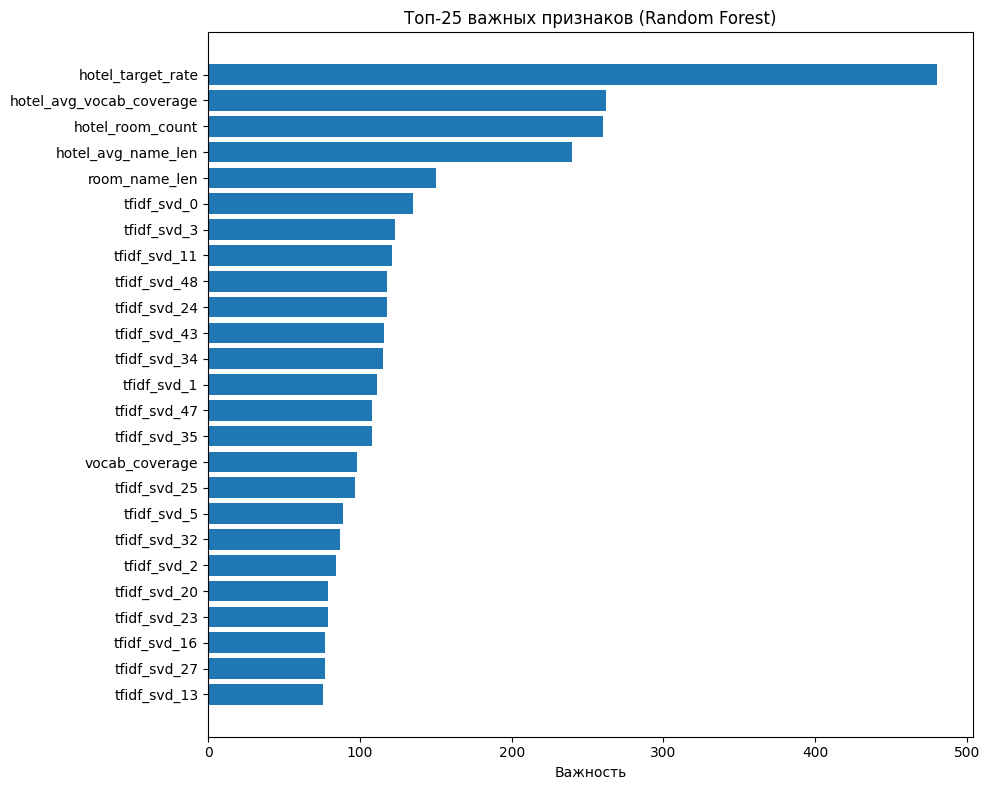


Топ-25 важных признаков:
                     feature  importance
0          hotel_target_rate         480
81  hotel_avg_vocab_coverage         262
11          hotel_room_count         260
2         hotel_avg_name_len         240
1              room_name_len         150
30               tfidf_svd_0         135
33               tfidf_svd_3         123
41              tfidf_svd_11         121
78              tfidf_svd_48         118
54              tfidf_svd_24         118
73              tfidf_svd_43         116
64              tfidf_svd_34         115
31               tfidf_svd_1         111
77              tfidf_svd_47         108
65              tfidf_svd_35         108
80            vocab_coverage          98
55              tfidf_svd_25          97
35               tfidf_svd_5          89
62              tfidf_svd_32          87
32               tfidf_svd_2          84


In [31]:

feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': best_model.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'][:25], feature_importance['importance'][:25])
plt.xlabel('Важность')
plt.title('Топ-25 важных признаков (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nТоп-25 важных признаков:")
print(feature_importance.head(20))

In [33]:
top_features = feature_importance['feature'].head(10).tolist()

X_train_top = X_train[top_features]
X_val_top = X_val[top_features]
X_test_top = X_test[top_features]

best_params = {k.replace('model__', ''): v for k, v in results[best_name]['best_params'].items()}

final_model = best_model.named_steps['model'].__class__(**best_params, random_state=42)
final_model.fit(X_train_top, y_train)

y_val_proba_final = final_model.predict_proba(X_val_top)[:, 1]
print(f"Лучшая модель: {best_name}")
print(f"PR-AUC после отбора топ признаков: {average_precision_score(y_val, y_val_proba_final):.4f}")

results[f'{best_name} (top features)'] = {
    'pr_auc': average_precision_score(y_val, y_val_proba_final),
    'y_val_proba': y_val_proba_final  # ← вот сюда
}

Лучшая модель: LightGBM
PR-AUC после отбора топ признаков: 0.8988


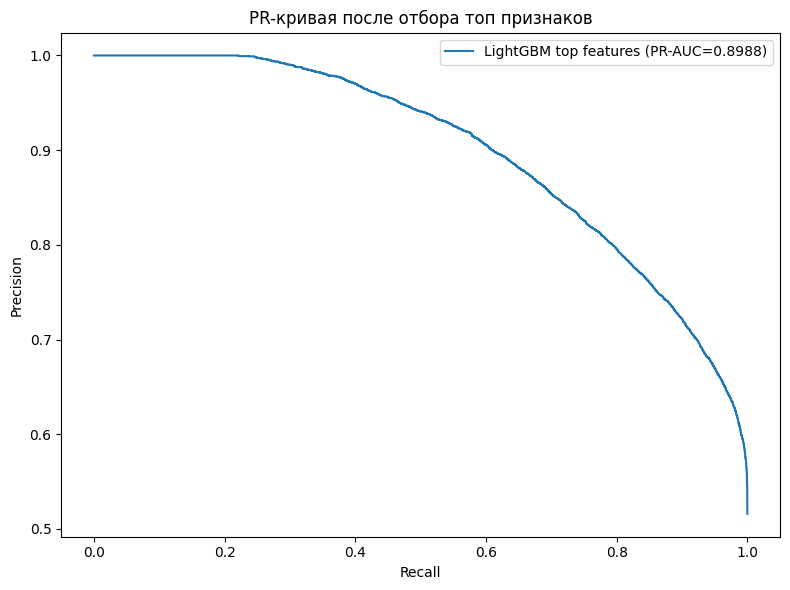

In [34]:
precision, recall, _ = precision_recall_curve(y_val, y_val_proba_final)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"{best_name} top features (PR-AUC={average_precision_score(y_val, y_val_proba_final):.4f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривая после отбора топ признаков')
plt.legend()
plt.tight_layout()
plt.show()


С использование лучших признаков Featutre Importance стало хуже

### **SHAP**

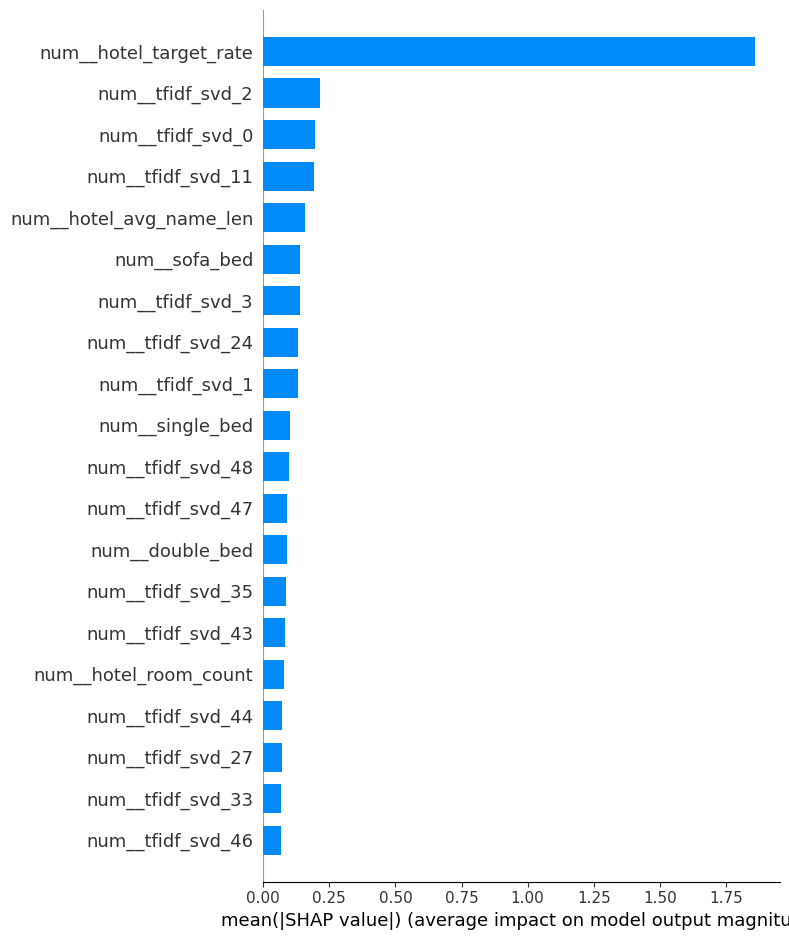

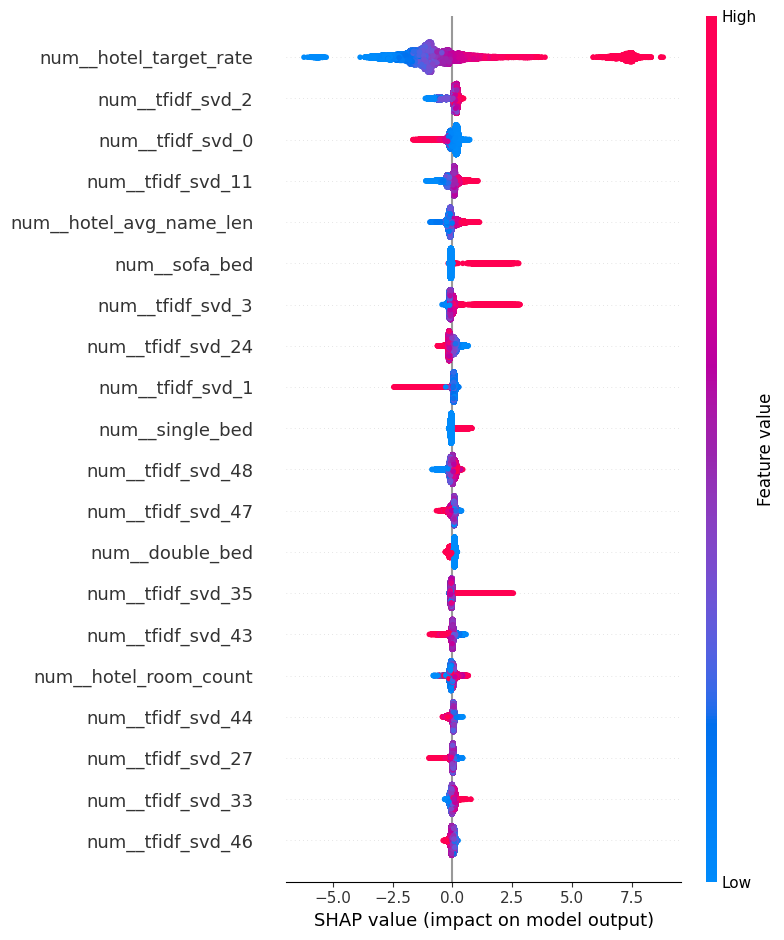

In [41]:


# Получаем трансформированные данные через Pipeline (все шаги кроме последнего)
X_val_transformed = best_model[:-1].transform(X_val)

# Получаем сам estimator
estimator = best_model.named_steps['model']

# Создаём explainer
explainer = shap.TreeExplainer(estimator)
shap_values = explainer.shap_values(X_val_transformed)

# Если классификация — берём класс 1
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# Имена признаков после трансформации (если ColumnTransformer меняет порядок)
try:
    feature_names = best_model[:-1].get_feature_names_out()
except:
    feature_names = selected_features

# Топ-20 признаков по среднему |SHAP|
shap.summary_plot(sv, X_val_transformed, feature_names=feature_names, max_display=20, plot_type='bar')

# Детальный plot — направление влияния
shap.summary_plot(sv, X_val_transformed, feature_names=feature_names, max_display=20)


In [48]:
# Средний SHAP по каждому признаку (с учётом знака)
mean_shap = pd.DataFrame({
    'feature': selected_features,
    'mean_shap': sv.mean(axis=0),        # со знаком — направление
    'abs_shap': np.abs(sv).mean(axis=0)  # без знака — важность
}).sort_values('abs_shap', ascending=False)

print(mean_shap.head(60))

                     feature  mean_shap  abs_shap
0          hotel_target_rate      -0.06      1.86
32               tfidf_svd_2       0.01      0.21
30               tfidf_svd_0      -0.02      0.20
41              tfidf_svd_11       0.00      0.19
2         hotel_avg_name_len      -0.00      0.16
5                   sofa_bed       0.00      0.14
33               tfidf_svd_3       0.01      0.14
54              tfidf_svd_24       0.00      0.13
31               tfidf_svd_1      -0.01      0.13
4                 single_bed       0.00      0.10
78              tfidf_svd_48      -0.00      0.10
77              tfidf_svd_47       0.00      0.09
3                 double_bed       0.01      0.09
65              tfidf_svd_35      -0.00      0.09
73              tfidf_svd_43      -0.00      0.08
11          hotel_room_count      -0.01      0.08
74              tfidf_svd_44       0.00      0.07
57              tfidf_svd_27       0.01      0.07
63              tfidf_svd_33       0.00      0.07


In [49]:
# Признаки с нулевым вкладом
useless = mean_shap[mean_shap['abs_shap'] < 0.001]['feature'].tolist()

# Признаки с устойчивым негативным влиянием
harmful = mean_shap[mean_shap['mean_shap'] < -0.01]['feature'].tolist()

print("Бесполезные:", useless)
print("Потенциально вредные:", harmful)

# Убираем из selected_features и переобучаем
selected_features_filtered = [f for f in selected_features if f not in useless + harmful]

Бесполезные: ['junior_suite', 'garden_view', 'has_bedroom_count']
Потенциально вредные: ['hotel_target_rate', 'tfidf_svd_0']


In [50]:
X_train_filtered = X_train[selected_features_filtered]
X_val_filtered = X_val[selected_features_filtered]
X_test_filtered = X_test[selected_features_filtered]

best_params = {k.replace('model__', ''): v for k, v in results[best_name]['best_params'].items()}

filtered_model = best_model.named_steps['model'].__class__(**best_params, random_state=42)
filtered_model.fit(X_train_filtered, y_train)

y_val_proba_filtered = filtered_model.predict_proba(X_val_filtered)[:, 1]
pr_auc_filtered = average_precision_score(y_val, y_val_proba_filtered)

print(f"PR-AUC до фильтрации:  {results[best_name]['pr_auc']:.4f}")
print(f"PR-AUC после фильтрации: {pr_auc_filtered:.4f}")

results[f'{best_name} (filtered)'] = {
    'pr_auc': pr_auc_filtered,
    'y_val_proba': y_val_proba_filtered
}


PR-AUC до фильтрации:  0.9352
PR-AUC после фильтрации: 0.9061


При удалении худших признаков по SHAP стало хуже.

Сохроаним первоначальную лучшую модель.

Сохраним лучшую модель в файл.

In [ ]:
# Финальный выбор лучшей модели из всех экспериментов
best_name = max(results, key=lambda x: results[x]['pr_auc'])
best_model = results[best_name]['model']

print(f"Лучшая модель: {best_name}")
print(f"PR-AUC: {results[best_name]['pr_auc']:.4f}")

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"Модель '{best_name}' сохранена в best_model.pkl")


Лучшая модель: LightGBM
PR-AUC: 0.9352
Модель 'LightGBM' сохранена в best_model.pkl


# **7. Итоги проекта**

## Задача
Разработана модель для детектирования номеров с недостаточным контентом до отправки в краудсорсинг. Это позволяет сократить расходы сервиса Т-Путешествия на пустые поиски.

## Данные
- **Датасет**: 184 138 записей с полями `hotel_id`, `supplier_room_name`, `target`
- **Целевая переменная**: `target = 1` — несматченная комната (ищем единички)
- **Метрика**: PR-AUC (важна полнота при высокой точности)

## Feature Engineering
Создано **82 признака** из текстового описания номера:
- **Базовые**: длина описания, количество слов
- **Бинарные флаги** по 26 группам ключевых слов (тип кровати, вид из окна, уровень номера и т.д.)
- **Агрегированные**: `amenity_count`, `completeness_score` (0–6), `has_*` флаги по критическим категориям
- **Отельная статистика**: `hotel_target_rate`, `hotel_avg_name_len`, `hotel_room_count`, `hotel_avg_vocab_coverage`
- **TF-IDF → SVD**: 50 компонент (добавлены после корреляционного фильтра)
- **Словарное покрытие**: `vocab_coverage`, `hotel_avg_vocab_coverage`

## Результаты моделей

| Модель | PR-AUC |
|--------|--------|
| Logistic Regression | 0.8815 |
| Random Forest | 0.9109 |
| **LightGBM** | **0.9352** |

**Лучшая модель: LightGBM** с параметрами:
- `n_estimators=300`, `learning_rate=0.1`, `max_depth=5`, `num_leaves=20`, `min_child_samples=15`

## Интерпретация модели (SHAP)
Наиболее важные признаки по SHAP:
1. **`hotel_target_rate`** (abs_shap=1.86) — доля несматченных номеров в отеле. Доминирующий признак: модель почти полностью опирается на него
2. **TF-IDF SVD компоненты** (tfidf_svd_2, tfidf_svd_0, tfidf_svd_11) — семантика текста описания
3. **`hotel_avg_name_len`** — средняя длина описания по отелю
4. **`sofa_bed`, `single_bed`, `double_bed`** — конфигурация кровати

**Вывод**: разница между отелями существенна — `hotel_target_rate` объясняет большую часть предсказаний. Отели с высокой долей несматченных номеров исторически продолжают поставлять неполные описания.

## Сохранённая модель
Лучшая модель сохранена в файл `best_model.pkl` для дальнейшего использования в продакшене.